In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import seaborn as sns
from scipy import stats

import inspect

from rwmcmc import acceptance_rate
from rwmcmc.targets import banana_log_pdf
from rwmcmc.samplers import random_walk_metropolis_hastings


In [2]:
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [8, 5]

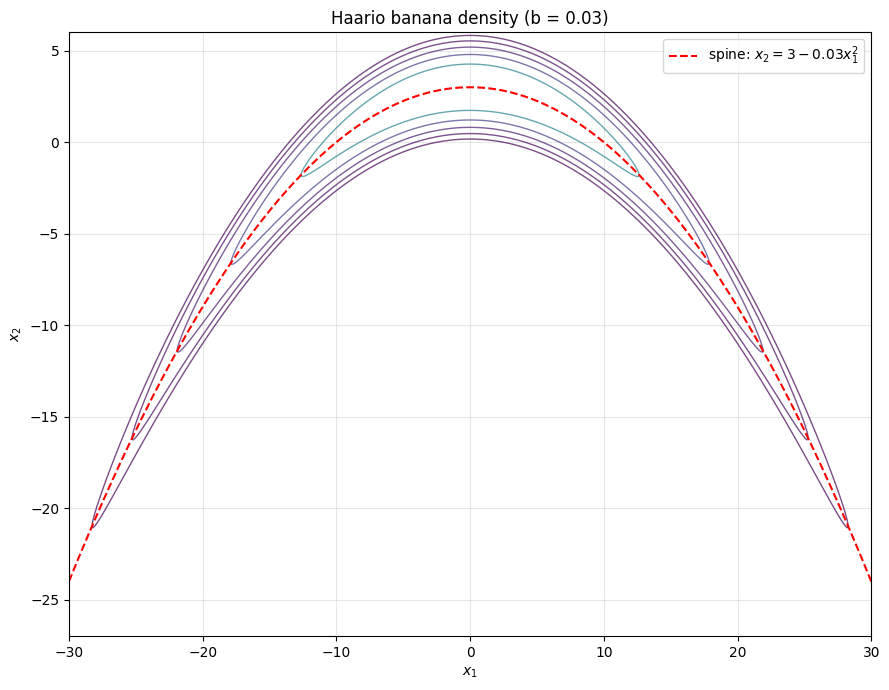

In [3]:
# Evaluate the Haario banana density on a grid.
sig = inspect.signature(banana_log_pdf)
b_default = sig.parameters["b"].default

x1_max = 30.0
x1_grid = np.linspace(-x1_max, x1_max, 400)

# The conditional mode is x2 = 100*b - b*x1**2.
x1_spine = np.linspace(-x1_max, x1_max, 400)
x2_spine = 100.0 * b_default - b_default * x1_spine**2

x2_grid = np.linspace(x2_spine.min() - 3.0, x2_spine.max() + 3.0, 400)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
points = np.stack([X1, X2], axis=-1)

log_p = banana_log_pdf(points)
density = np.exp(log_p)

fig, ax = plt.subplots(figsize=(9, 7))

levels = np.exp(np.linspace(log_p.max() - 4.0, log_p.max(), 6))
ax.contour(X1, X2, density, levels=levels, linewidths=1.0, alpha=0.7)
ax.plot(
    x1_spine,
    x2_spine,
    "r--",
    linewidth=1.5,
    label=rf"spine: $x_2 = {100 * b_default:g} - {b_default:g}x_1^2$",
)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title(f"Haario banana density (b = {b_default:g})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
rng = np.random.default_rng(seed=42)

samples, accepted = random_walk_metropolis_hastings(
    target_log_pdf=banana_log_pdf,
    x0=[0.0, 3.0],
    n_samples=50_000,
    step_size=[4.0, 2.0],
    rng=rng,
)

burn_in = 5_000
posterior = samples[burn_in:]
true_x2_std = np.sqrt(1.0 + 20_000.0 * b_default**2)

print(f"Samples shape:   {samples.shape}")
print(f"Acceptance rate: {acceptance_rate(accepted):.3f}")
print(f"x1 sample mean:  {posterior[:, 0].mean():.4f}  (true: 0.0)")
print(f"x2 sample mean:  {posterior[:, 1].mean():.4f}  (true: 0.0)")
print(f"x1 sample std:   {posterior[:, 0].std():.4f}  (true: 10.0)")
print(f"x2 sample std:   {posterior[:, 1].std():.4f}  (true: {true_x2_std:.4f})")


Samples shape:   (50000, 2)
Acceptance rate: 0.382
x1 sample mean:  -0.8283  (true: 0.0)
x2 sample mean:  -0.0113  (true: 0.0)
x1 sample std:   9.9758  (true: 10.0)
x2 sample std:   4.3127  (true: 4.3589)


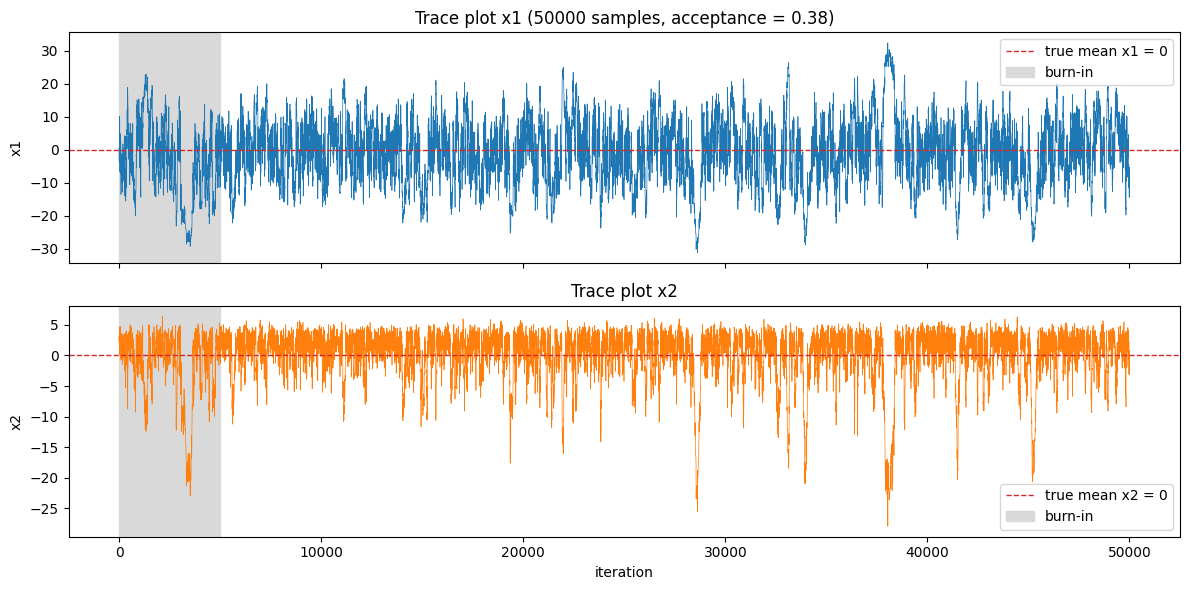

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(samples[:, 0], linewidth=0.5, color="C0")
axes[0].axhline(0.0, color="C3", linestyle="--", linewidth=1, label="true mean x1 = 0")
axes[0].axvspan(0, burn_in, color="0.85", label="burn-in")
axes[0].set_ylabel("x1")
axes[0].set_title(
    f"Trace plot x1 ({len(samples)} samples, acceptance = {acceptance_rate(accepted):.2f})"
)
axes[0].legend()

axes[1].plot(samples[:, 1], linewidth=0.5, color="C1")
axes[1].axhline(0.0, color="C3", linestyle="--", linewidth=1, label="true mean x2 = 0")
axes[1].axvspan(0, burn_in, color="0.85", label="burn-in")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("x2")
axes[1].set_title("Trace plot x2")
axes[1].legend()

plt.tight_layout()
plt.show()


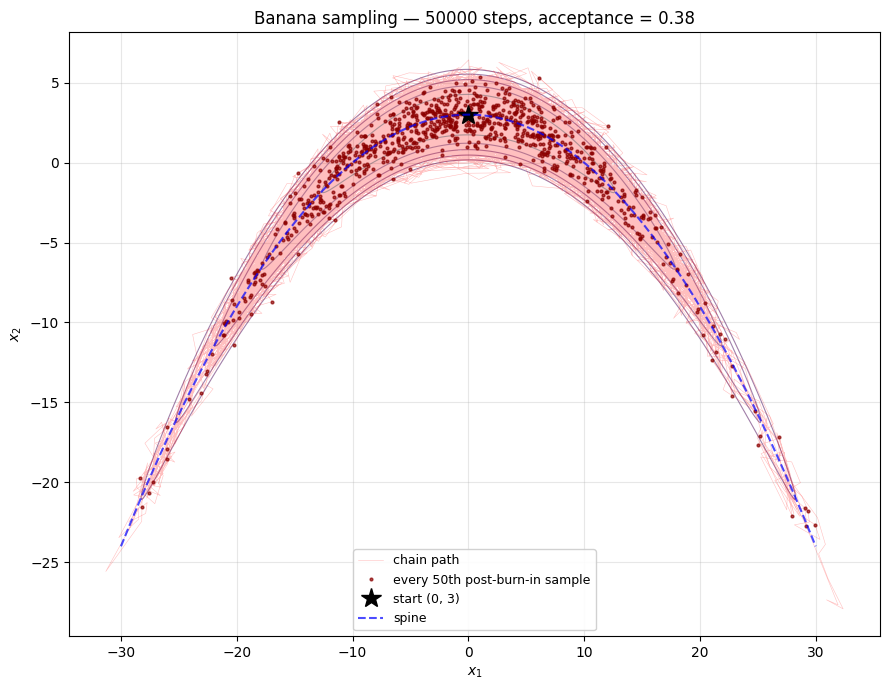

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.contour(X1, X2, density, levels=levels, cmap="viridis", linewidths=0.8, alpha=0.5)
ax.plot(
    samples[:, 0],
    samples[:, 1],
    "-",
    color="red",
    linewidth=0.4,
    alpha=0.25,
    label="chain path",
)

thin = posterior[::50]
ax.plot(
    thin[:, 0],
    thin[:, 1],
    ".",
    color="darkred",
    markersize=4,
    alpha=0.7,
    label="every 50th post-burn-in sample",
)

ax.plot(samples[0, 0], samples[0, 1], "k*", markersize=15, label="start (0, 3)")
ax.plot(x1_spine, x2_spine, "b--", linewidth=1.5, alpha=0.7, label="spine")

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title(f"Banana sampling — {len(samples)} steps, acceptance = {acceptance_rate(accepted):.2f}")
ax.legend(loc="lower center", fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


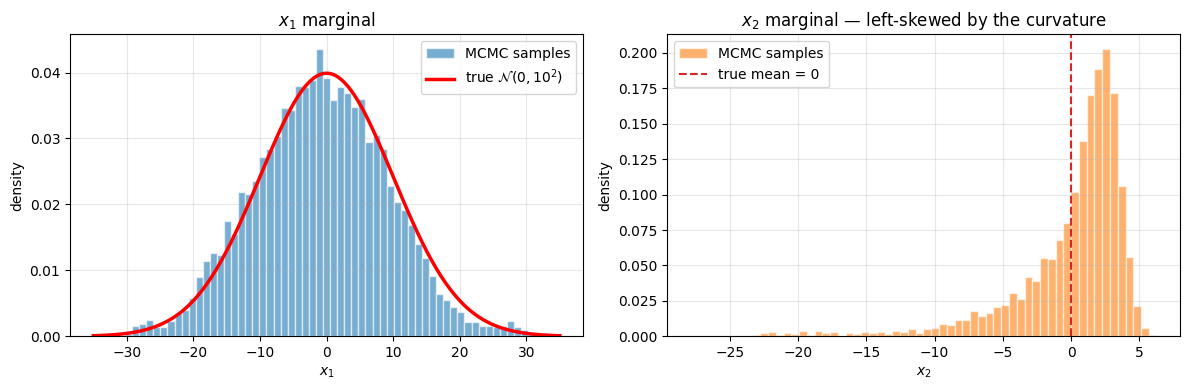

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(
    posterior[:, 0],
    bins=60,
    density=True,
    alpha=0.6,
    color="C0",
    edgecolor="white",
    label="MCMC samples",
)
x1_range = np.linspace(-35.0, 35.0, 300)
x1_density = np.exp(-0.5 * (x1_range / 10.0) ** 2) / (10.0 * np.sqrt(2.0 * np.pi))
axes[0].plot(
    x1_range,
    x1_density,
    "r-",
    linewidth=2.5,
    label=r"true $\mathcal{N}(0, 10^2)$",
)
axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel("density")
axes[0].set_title(r"$x_1$ marginal")
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].hist(
    posterior[:, 1],
    bins=60,
    density=True,
    alpha=0.6,
    color="C1",
    edgecolor="white",
    label="MCMC samples",
)
axes[1].axvline(0.0, color="C3", linestyle="--", linewidth=1.5, label="true mean = 0")
axes[1].set_xlabel(r"$x_2$")
axes[1].set_ylabel("density")
axes[1].set_title(r"$x_2$ marginal — left-skewed by the curvature")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


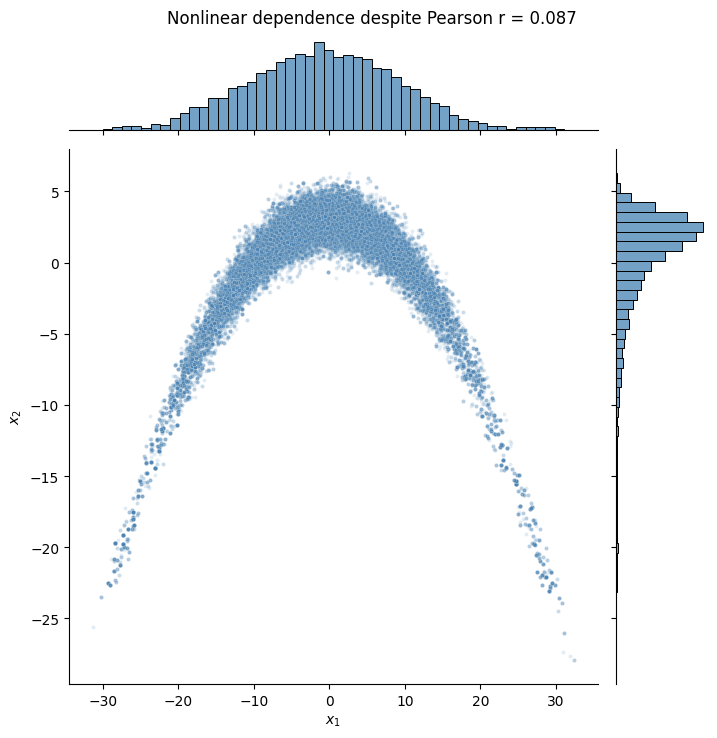

In [8]:
g = sns.jointplot(
    x=posterior[:, 0],
    y=posterior[:, 1],
    kind="scatter",
    s=8,
    alpha=0.15,
    color="steelblue",
    height=7,
    marginal_kws=dict(bins=50),
)
g.set_axis_labels(r"$x_1$", r"$x_2$")

pearson_r, p_value = stats.pearsonr(posterior[:, 0], posterior[:, 1])
g.fig.suptitle(
    f"Nonlinear dependence despite Pearson r = {pearson_r:.3f}",
    y=1.02,
)

plt.show()
